## Imports

In [1]:
import pickle
from itertools import zip_longest

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.patches import Rectangle
from scipy.spatial.distance import cdist
from tqdm.notebook import tqdm

from analysis_helpers import Episode, Participant
from analysis_helpers.constants import EVENTSEG_EDGECOLOR, FIG_DIR, HEATMAP_CMAP

## Functions

In [2]:
def segment_recall(
    rec_ep_similarity, 
    fwd_transition_penalty=1.5, 
    other_transition_penalty=3.0
):
    n_recall_tpts, n_episode_events = rec_ep_similarity.shape

    # emission fit (z-score so transition penalties are equivalent across recalls)
    emission_scores = (
        (rec_ep_similarity - rec_ep_similarity.mean()) 
        / (rec_ep_similarity.std() + 1e-8)
    )
    
    # log transition cost matrix
    ep_events_ixs = np.arange(n_episode_events)
    lags = ep_events_ixs[None, :] - ep_events_ixs[:, None]
    log_transition_costs = np.full((n_episode_events, n_episode_events), 
                                   -other_transition_penalty, 
                                   dtype=float)
    log_transition_costs[lags == 1] = -fwd_transition_penalty
    np.fill_diagonal(log_transition_costs, 0)

    # Viterbi forward pass: best score of any label-path ending in each event
    delta = emission_scores[0].copy()
    backpointers = np.zeros((n_recall_tpts, n_episode_events), int)
    for rec_tpt in range(1, n_recall_tpts):
        scores = delta[:, None] + log_transition_costs
        backpointers[rec_tpt] = scores.argmax(axis=0)
        delta = scores.max(axis=0) + emission_scores[rec_tpt]

    # backtrack to recover best label sequence
    state_labels = np.empty(n_recall_tpts, int)
    state_labels[-1] = delta.argmax()
    for rect_tpt in range(n_recall_tpts - 2, -1, -1):
        state_labels[rect_tpt] = backpointers[rect_tpt + 1, state_labels[rect_tpt + 1]]

    # collapse consecutive identical labels into events
    changes = np.flatnonzero(np.diff(state_labels) != 0) + 1
    starts = np.concatenate(([0], changes))
    stops = np.concatenate((changes - 1, [n_recall_tpts - 1]))
    event_bounds = np.column_stack((starts, stops))
    event_matches = np.array([state_labels[s] for s in starts])
    
    return event_bounds, event_matches

In [3]:
def create_event_trajectory(trajectory, event_onsets):
    """
    Note: event_onsets is a 1D array of indicies of the first timepoint 
    for each event (optionally including/excluding the first, i.e., tpt 0)
    """
    event_onsets = np.asarray(event_onsets, dtype=int)
    if event_onsets[0] == 0:
        event_onsets = event_onsets[1:]
    
    chunks = np.split(trajectory, event_onsets)
    return np.vstack([chunk.mean(axis=0) for chunk in chunks])

In [4]:
def draw_event_bounds(ax, event_bounds, **rect_kwargs):
    facecolor = rect_kwargs.pop('facecolor', rect_kwargs.pop('fc', 'none'))
    patches = []
    for onset, offset in event_bounds:
        size = offset - onset + 1
        rect = Rectangle((onset - 0.5, onset - 0.5), 
                         width=size, 
                         height=size, 
                         edgecolor=EVENTSEG_EDGECOLOR, 
                         facecolor=facecolor,
                         **rect_kwargs)
        ax.add_patch(rect)
        patches.append(rect)
    return patches

## Load data

In [5]:
atlep1 = Episode('atlep1')

participants = Participant.load_all()
avg_participant = Participant('average')

N_EVENTS_RANGE = np.arange(2, 51)

## Load episode $K$-optimization results from HPC cluster, segment trajectory and save
see [code/cluster-scripts/eventseg/](https://github.com/ContextLab/memory-dynamics/tree/master/code/cluster-scripts/eventseg)

In [6]:
episode_event_labels = atlep1.eventseg_model.segments_[0].argmax(axis=1)
episode_event_onsets = np.flatnonzero(np.diff(episode_event_labels)) + 1

# atlep1.events = create_event_trajectory(atlep1.trajectory, episode_event_bounds)
# np.save(atlep1.data_dir.joinpath('events.npy'), atlep1.events)

## Plot episode $K$-optimization curve & event boundaries

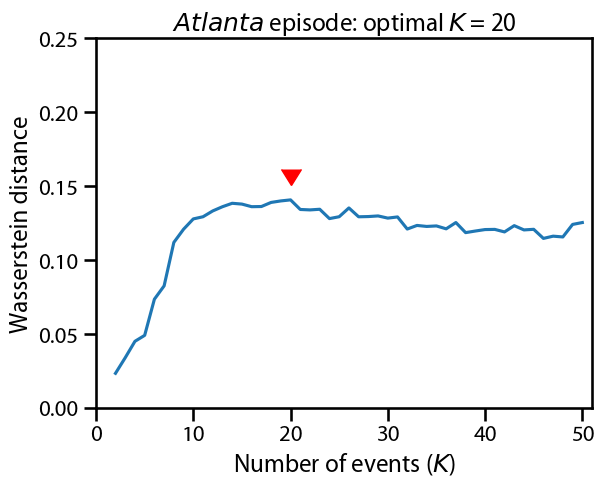

In [7]:
with sns.plotting_context('talk'):
    episode_best_k = N_EVENTS_RANGE[atlep1.eventseg_kvals.argmax()]
    ax = sns.lineplot(x=N_EVENTS_RANGE, y=atlep1.eventseg_kvals)
    ax.plot(episode_best_k, atlep1.eventseg_kvals.max() + 0.01, c='r', marker=7, markersize=15)
    ax.set_xlim(0, N_EVENTS_RANGE[-1] + 1)
    ax.set_ylim(0, 0.25)
    ax.set_xlabel('Number of events ($K$)')
    ax.set_ylabel('Wasserstein distance')
    ax.set_title(fr'$\it{{Atlanta}}$ episode: optimal $K$ = {episode_best_k}')
#     plt.savefig(FIG_DIR / f'k-optimization-episode.pdf', bbox_inches='tight')
    plt.show()

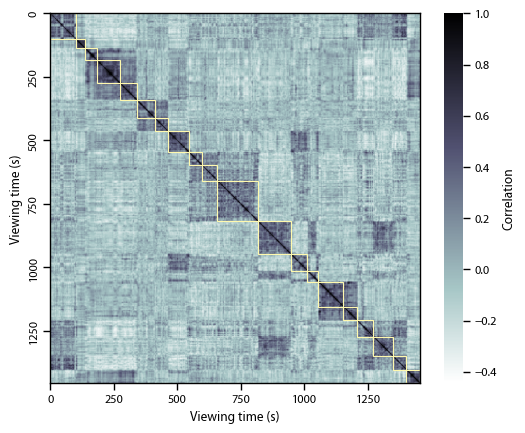

In [8]:
with sns.plotting_context('paper'):
    ax = sns.heatmap(np.corrcoef(atlep1.trajectory - atlep1.trajectory.mean(axis=0)), 
                     cmap=HEATMAP_CMAP, 
                     xticklabels=250, 
                     yticklabels=250,
                     cbar_kws={'label': 'Correlation'})
    ax.collections[0].remove()
    ax.imshow(np.corrcoef(atlep1.trajectory - atlep1.trajectory.mean(axis=0)), cmap=HEATMAP_CMAP)
    ax.set_xlabel('Viewing time (s)')
    ax.set_ylabel('Viewing time (s)')
    for spine in ax.spines.values():
        spine.set_visible(True)
    draw_event_bounds(ax, atlep1.event_bounds)
#     plt.savefig(FIG_DIR / 'episode-corrmat.pdf', bbox_inches='tight')
    plt.show()

## Segment recall trajectories by episode-similarity time series

In [9]:
episode_events_centered = atlep1.events - atlep1.events.mean(axis=0)

for rectype in ('atlep1', 'delayed'):
    for p in participants:
        recall_trajectory = p.trajectories[rectype]
        recall_trajectory_centered = recall_trajectory - recall_trajectory.mean(axis=0)
        similarity_timeseries = 1 - cdist(recall_trajectory_centered, 
                                          episode_events_centered, 
                                          'cosine')
        event_bounds, event_matches = segment_recall(similarity_timeseries)
        recall_events = create_event_trajectory(recall_trajectory, event_bounds[:, 0])
        
        p.event_bounds[rectype] = event_bounds
        p.event_matches[rectype] = event_matches
        p.events[rectype] = recall_events
        
#         np.save(p.data_dir / f'{rectype}_recall_event_bounds.npy', event_bounds)
#         np.save(p.data_dir / f'{rectype}_recall_event_matches.npy', event_matches)
#         np.save(p.data_dir / f'{rectype}_recall_events.npy', event_matches)

## Plot episode-recall similarity time series & correlation matrices with event overlay

In [10]:
N_COLS = 6
N_ROWS = int(len(participants) / N_COLS) + 1

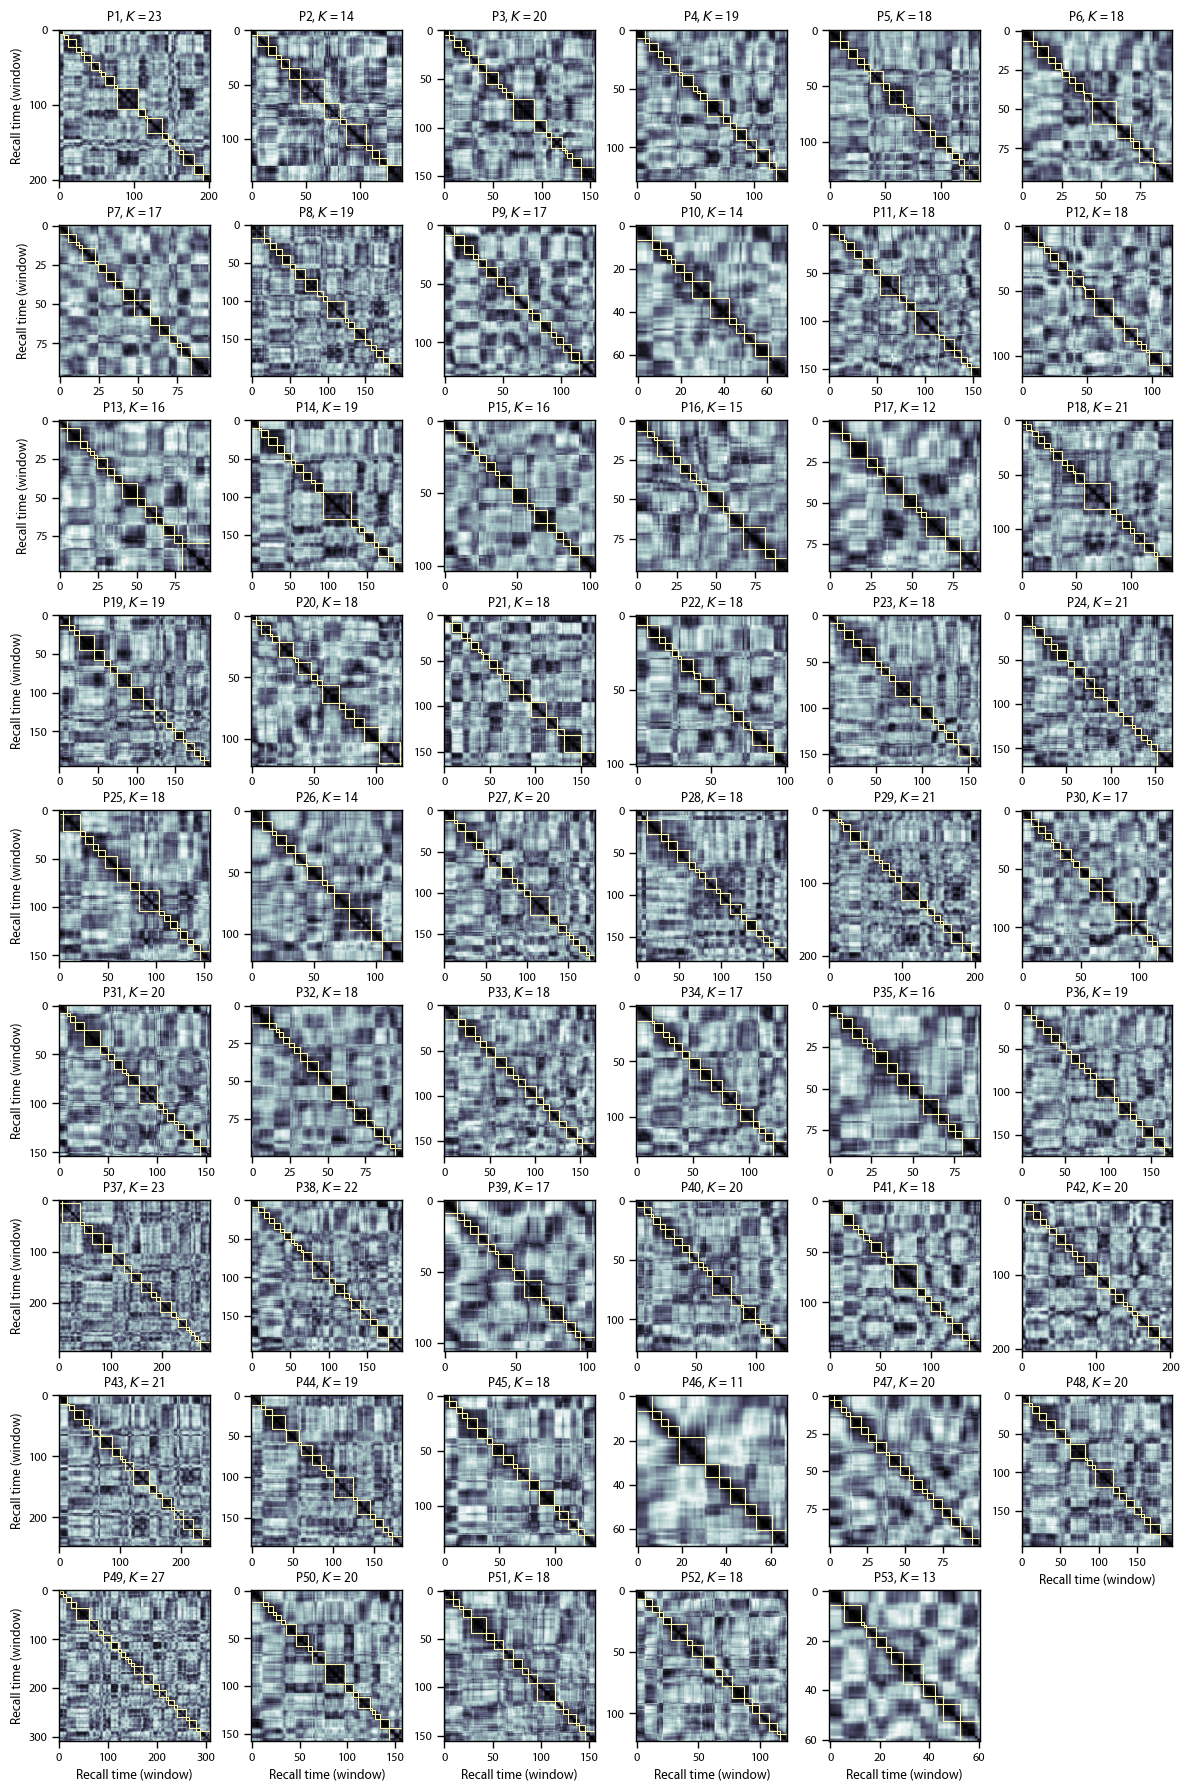

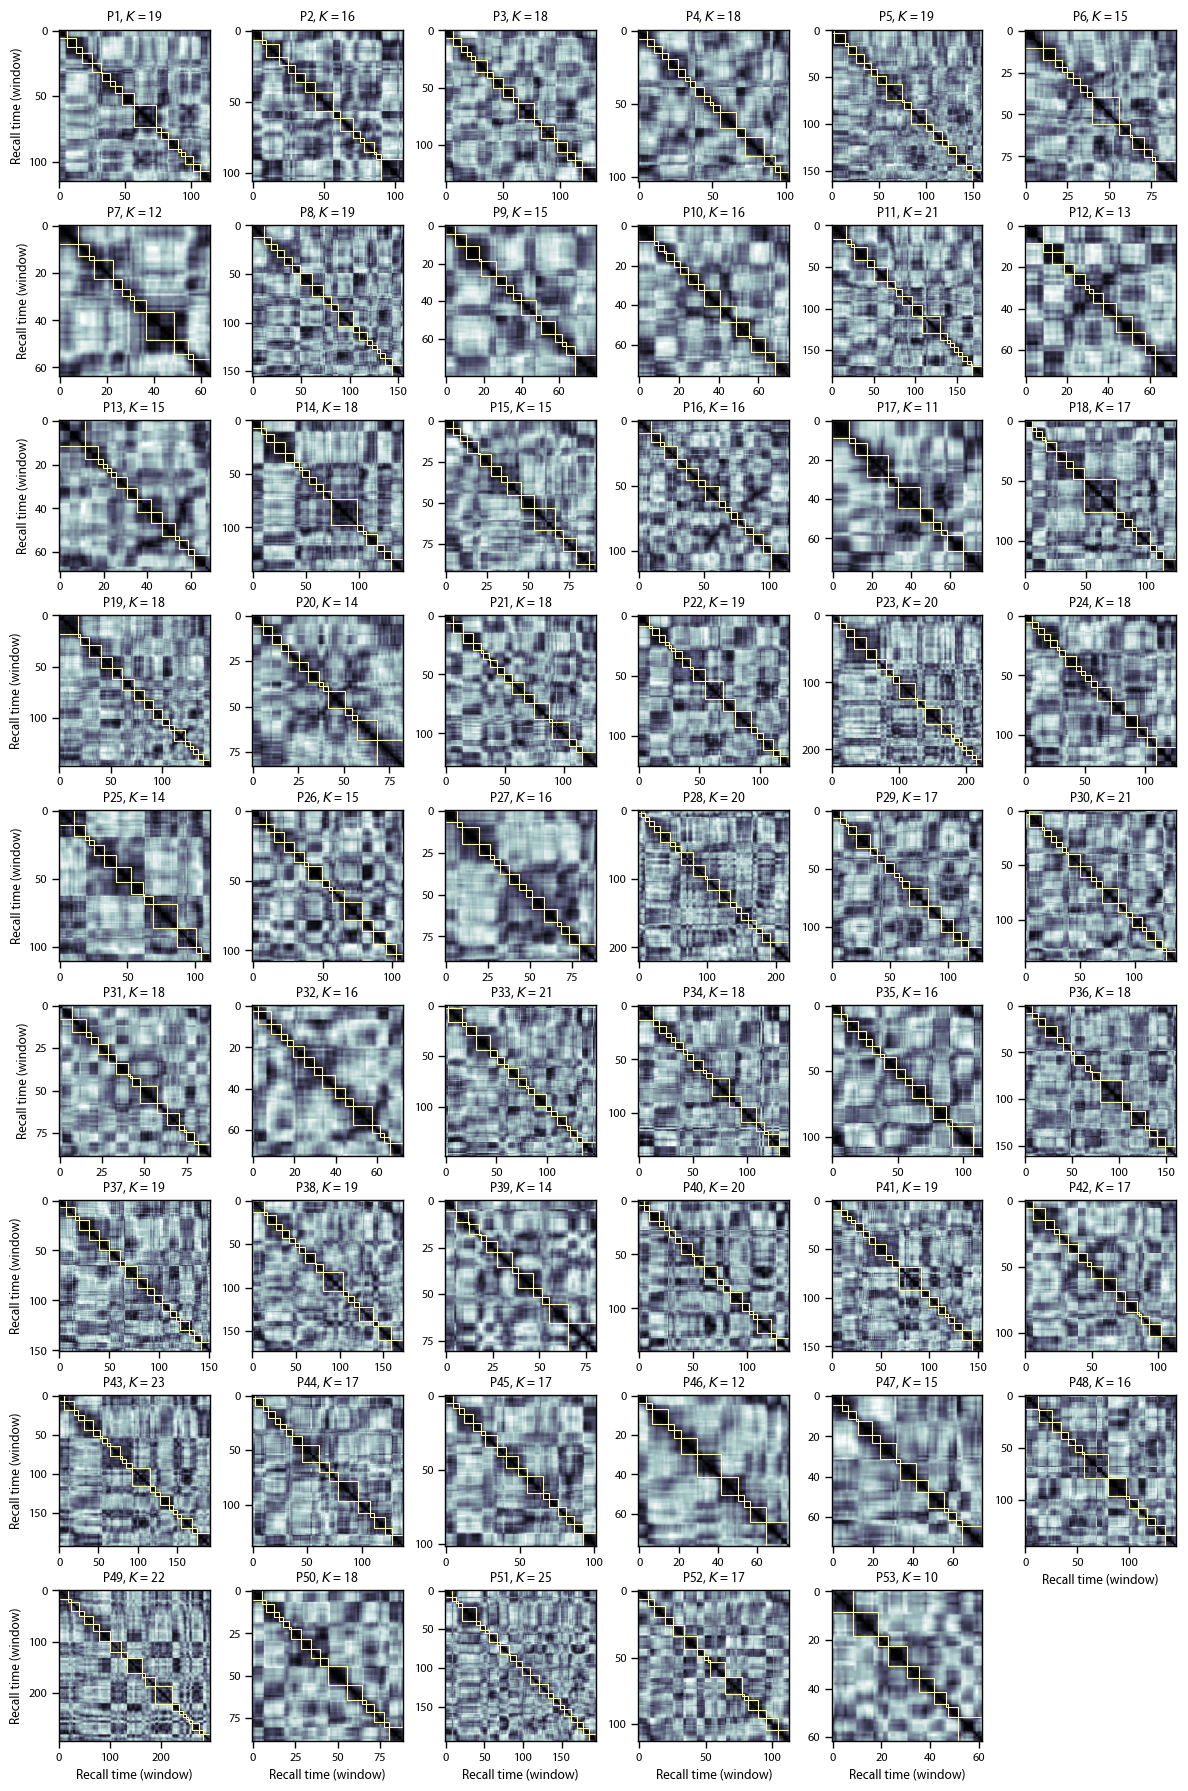

In [11]:
with sns.plotting_context('paper'):
    for rectype in ('atlep1', 'delayed'):
        fig, axarr = plt.subplots(nrows=N_ROWS, ncols=N_COLS, figsize=(12, 18))
        for i, (p, ax) in enumerate(zip_longest(participants, axarr.ravel())):
            if p is None:
                ax.axis('off')
                continue
                
            recall_trajectory = p.trajectories[rectype]
            recall_trajectory_centered = recall_trajectory - recall_trajectory.mean(axis=0)
            similarity_timeseries = 1 - cdist(recall_trajectory_centered, 
                                              episode_events_centered, 
                                              'cosine')
            event_bounds =  p.event_bounds[rectype]
            ax.imshow(np.corrcoef(similarity_timeseries), cmap=HEATMAP_CMAP)
            draw_event_bounds(ax, event_bounds)
                
            ax.set_title(f'P{p.sub_n}, $K$ = {len(event_bounds)}')
            
            if i >= len(participants) - N_COLS:
                ax.set_xlabel('Recall time (window)')
                
            if not i % N_COLS:
                ax.set_ylabel('Recall time (window)')

        plt.tight_layout(h_pad=0.2, w_pad=0.1)
        
        # make x- and y-axes use the same tick frequency
        for ax in axarr.ravel():
            if ax.has_data():
                xlim, ylim = ax.get_xlim(), ax.get_ylim()
                x_min, x_max = xlim
                xticks = [t for t in ax.get_xticks() if x_min <= t <= x_max]
                ax.set_xticks(xticks)
                ax.set_yticks(xticks)

                ax.set_xlim(xlim)
                ax.set_ylim(ylim)


#         plt.savefig(FIG_DIR / f'{rectype}-recall-corrmats.pdf', bbox_inches='tight')
        plt.show()

In [ ]:
with sns.plotting_context('paper'):
    for rectype in ('atlep1', 'delayed'):
        fig, axarr = plt.subplots(nrows=N_ROWS, ncols=N_COLS, figsize=(12, 18))
        for i, (p, ax) in enumerate(zip_longest(participants, axarr.ravel())):
            if p is None:
                ax.axis('off')
                continue
                
            recall_trajectory = p.trajectories[rectype]
            recall_trajectory_centered = recall_trajectory - recall_trajectory.mean(axis=0)
            similarity_timeseries = 1 - cdist(recall_trajectory_centered, 
                                              episode_events_centered, 
                                              'cosine')
            
            aspect_ratio = similarity_timeseries.shape[0] / similarity_timeseries.shape[1]
            ax.imshow(similarity_timeseries.T, cmap=HEATMAP_CMAP, aspect=aspect_ratio)
            
            event_bounds = p.event_bounds[rectype]
            event_matches = p.event_matches[rectype]
            for (onset, offset), match_ix in zip(event_bounds, event_matches):
                rect = Rectangle((onset - 0.5, match_ix - 0.5), 
                                 width=offset - onset + 1, 
                                 height=1, 
                                 linewidth=1,
                                 edgecolor=EVENTSEG_EDGECOLOR,
                                 facecolor='none')
                ax.add_patch(rect)
                
            ax.set_title(f'P{p.sub_n}, $K$ = {len(event_bounds)}')
            
            if i >= len(participants) - N_COLS:
                ax.set_xlabel('Recall time (window)')
                
            if not i % N_COLS:
                ax.set_ylabel('Episode event')
            else:
                ax.set_yticklabels([])
                
        plt.tight_layout(h_pad=0.2, w_pad=0.1)
#         plt.savefig(FIG_DIR / f'{rectype}-recall-similarity-heatmaps.pdf', bbox_inches='tight')
        plt.show()

## Plot event match matrices

In [ ]:
with sns.plotting_context('paper'):
    for rectype in ('atlep1', 'delayed'):
        fig, axarr = plt.subplots(nrows=N_ROWS, ncols=N_COLS, figsize=(12, 18))
        for i, (p, ax) in enumerate(zip_longest(participants, axarr.ravel())):
            if p is None:
                ax.axis('off')
                continue
                
            recall_events = p.events[rectype]
            recall_events_centered = recall_events - recall_events.mean(axis=0)
            matchmat = 1 - cdist(episode_events_centered, 
                                 recall_events_centered, 
                                 'cosine')
            
            sns.heatmap(matchmat, 
                        cmap=HEATMAP_CMAP, 
                        xticklabels=5, 
                        yticklabels=5, 
                        cbar=False, 
                        ax=ax)
            
            ax.set_box_aspect(1)
            
            for spine in ax.spines.values():
                spine.set_visible(True)
            
            ax.hlines(range(matchmat.shape[0]), *ax.get_xlim(), linewidth=0.25)
            ax.vlines(range(matchmat.shape[1]), *ax.get_ylim(), linewidth=0.25)
            
            event_matches = p.event_matches[rectype]
            for rec_event_ix, ep_event_ix in enumerate(event_matches):
                rect = Rectangle((rec_event_ix, ep_event_ix), 
                                 width=1, 
                                 height=1, 
                                 edgecolor=EVENTSEG_EDGECOLOR, 
                                 facecolor='none', 
                                 zorder=2)
                ax.add_patch(rect)
            
            ax.set_title(f'P{p.sub_n}, $K$ = {len(event_matches)}')
            
            if i >= len(participants) - N_COLS:
                ax.set_xlabel(f'Recall event')

            if not i % N_COLS:
                ax.set_ylabel(f'Episode event')
            else:
                ax.set_yticklabels([])
                
        plt.tight_layout(h_pad=0.2, w_pad=0.1)
#         plt.savefig(FIG_DIR / f'{rectype}-recall-matchmats.pdf', bbox_inches='tight')
        plt.show()